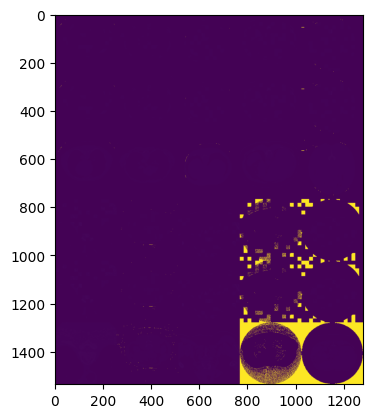

epoch   0: 17375.01943359375


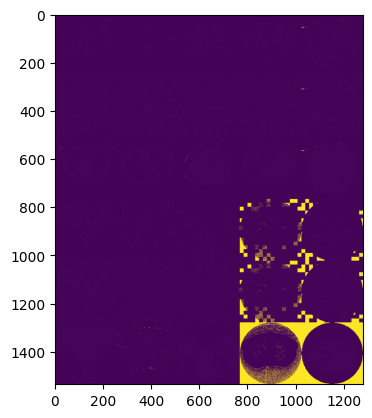

epoch   1: 17226.623620605467
epoch   2: 16733.075146484374
epoch   3: 15434.836193847656
epoch   4: 13103.77010498047
epoch   5: 11580.674560546875
epoch   6: 9173.509167480468
epoch   7: 8045.034228515625
epoch   8: 8992.513366699219
epoch   9: 8140.7763671875
epoch  10: 7273.195520019532
epoch  11: 7672.895471191407
epoch  12: 7149.357995605469
epoch  13: 7776.757958984375
epoch  14: 7223.856970214843
epoch  15: 7369.007971191406
epoch  16: 7185.339465332031
epoch  17: 6912.939416503907
epoch  18: 7031.55166015625
epoch  19: 7099.884387207031
epoch  20: 6913.2130126953125


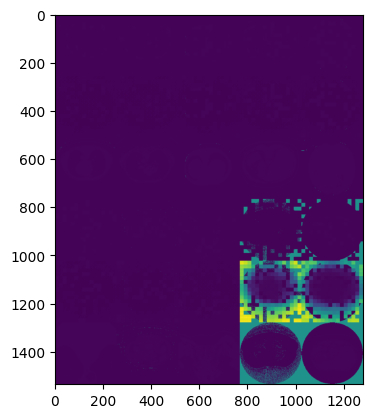

epoch  21: 6846.026513671875
epoch  22: 7007.675915527344
epoch  23: 6907.2859375
epoch  24: 6937.510095214844
epoch  25: 7051.158959960938
epoch  26: 6875.246301269532
epoch  27: 6853.566857910157
epoch  28: 6697.6623046875
epoch  29: 6792.975439453125
epoch  30: 6690.217041015625
epoch  31: 6564.260229492187
epoch  32: 6646.641528320312
epoch  33: 6642.899938964843
epoch  34: 6490.577600097657
epoch  35: 6538.71630859375
epoch  36: 6465.736804199219
epoch  37: 6407.672912597656
epoch  38: 6370.03583984375
epoch  39: 6312.510424804687
epoch  40: 6345.763171386719


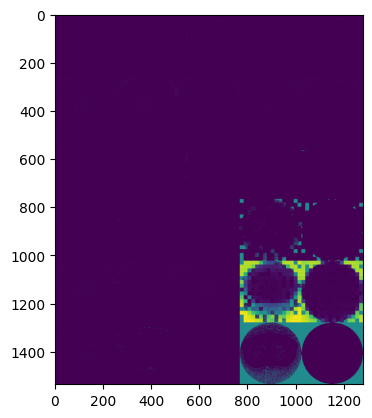

epoch  41: 6308.021508789063
epoch  42: 6212.684948730469
epoch  43: 6224.372277832032
epoch  44: 6185.414013671875
epoch  45: 6192.0506591796875
epoch  46: 6140.503747558594
epoch  47: 6185.543835449219
epoch  48: 6106.365649414062
epoch  49: 6133.831384277344


In [3]:
import math
import argparse
from tqdm import tqdm

import torch
import torchvision
import matplotlib.pyplot as plt
from torchvision.transforms.v2 import ToTensor
from sklearn.model_selection import train_test_split

from MAE.model import *
from src import dataset
from src import configs as cfg
from src import metrics
from MAE.utils import setup_seed


def eval_model(model: torch.nn.Module, valid_loader):
    ''' visualize the first 16 predicted images on val dataset'''
    model.eval()
    with torch.no_grad():
        (val_img, ) = next(iter(valid_loader))
        val_img = val_img.to(device=cfg.DEVICE, dtype=torch.float)
        # print(len(val_img))
        # val_img = torch.stack([val_dataset[i][0] for i in range(16)])
        val_img = val_img.to(device)[:10]
        predicted_val_img, mask = model(val_img)
        predicted_val_img = predicted_val_img * mask + val_img * (1 - mask)
        img = torch.cat([val_img * (1 - mask), predicted_val_img, val_img], dim=0)
        img = rearrange(img, '(v h1 w1) c h w -> c (h1 h) (w1 v w)', w1=2, v=3)
        plt.imshow(img.detach().cpu().numpy().swapaxes(0, 2))
        plt.show()

if __name__ == '__main__':
    seed=42
    batch_size=512
    max_lr=5e-4
    weight_decay=0.05
    mask_ratio=0.75
    total_epoch=50
    warmup_epoch=15
    model_path='vit-t-mae.pt'

    setup_seed(seed)
    torch.backends.cuda.matmul.fp32_precision = 'ieee'
    batch_size = load_batch_size = batch_size

    assert batch_size % load_batch_size == 0
    steps_per_update = batch_size // load_batch_size

    # train_dataset = torchvision.datasets.CIFAR10('data', train=True, download=True, transform=ToTensor())
    # val_dataset = torchvision.datasets.CIFAR10('data', train=False, download=True, transform=ToTensor())
    dataset.mk_dataset(verbose=False)
    train_cfg = cfg.TrainingConfig(batch_size=64)
    model_cfg = cfg.ModelConfig()
    dataset_cfg = cfg.DatasetConfig()

    x_train, y_train, x_test = dataset.load_preprocessed_dataset()
    x_train, x_valid, y_train, y_valid = train_test_split(
        x_train,
        y_train,
        test_size=dataset_cfg.test_size,
        random_state=train_cfg.random_state,
    )
    train_tensor = torch.cat((x_train, x_test)).to(device="cuda", dtype=torch.uint8)
    train_ds = torch.utils.data.TensorDataset(train_tensor)
    train_loader = torch.utils.data.DataLoader(train_ds, train_cfg.batch_size)

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    device_type = torch.device(device).type
    model = MAE_ViT(
        image_size=256,
        mask_ratio=mask_ratio,
        patch_size=16,
        emb_dim=128,
        encoder_layer=6,
        encoder_head=8,
        decoder_head=8,
    ).to(device)
    optim = torch.optim.AdamW(
        model.parameters(),
        lr=max_lr * batch_size / 256, betas=(0.9, 0.95),
        weight_decay=weight_decay,
    )
    lr_func = lambda epoch: min((epoch + 1) / (warmup_epoch + 1e-8), 0.5 * (math.cos(epoch / total_epoch * math.pi) + 1))
    lr_scheduler = torch.optim.lr_scheduler.LambdaLR(optim, lr_lambda=lr_func)

    eval_model(model, train_loader)
    step_count = 0
    for e in range(total_epoch):
        model.train()
        losses = []
        for (img,) in train_loader:
            img = img.to(device=cfg.DEVICE, dtype=torch.float)
            optim.zero_grad()
            step_count += 1
            img = (img.to(device) - 0.5) / 0.5
            with torch.autocast(device_type, torch.bfloat16):
                predicted_img, mask = model(img)
                loss = torch.mean((predicted_img - img) ** 2 * mask) / mask_ratio
            loss.backward()
            if step_count % steps_per_update == 0:
                optim.step()
            losses.append(loss.item())
        lr_scheduler.step()
        avg_loss = sum(losses) / len(losses)
        print(f'epoch {e:3d}: {avg_loss}')
        ''' save model '''
        torch.save(model, model_path)
        if e % 20 == 0:
            eval_model(model, train_loader)